In [1]:
from Bio.KEGG.KGML import KGML_parser
from Bio.Graphics.KGML_vis import KGMLCanvas

# Leer tu archivo modificado
pathway = KGML_parser.read(open("resultado/reh01200.xml"))



In [2]:
import pandas as pd
import numpy as np 
data = pd.read_csv('resultado/06_kegg_continuo.txt', sep=' ', header=None)

In [3]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [4]:
cmap = plt.get_cmap('coolwarm')


def get_hex_color(value, norm):
    
    """Convierte un valor numérico a color hexadecimal usando vlag"""
    rgba = cmap(norm(value))
    return mcolors.to_hex(rgba)

In [5]:
def change_color(pathway, gen_buscado, log2FC, values):
    norm = mcolors.TwoSlopeNorm(vcenter=values.mean(), vmin=values.min(), vmax=values.max()) 
    for entry in pathway.entries.values():
        if gen_buscado in entry.name:

            for graphic in entry.graphics:

                graphic.bgcolor = get_hex_color(log2FC, norm)
                graphic.fgcolor = get_hex_color(log2FC, norm)
                graphic.width = 3
    return pathway


def min_max_mean(pathway, gen_buscado, log2FC):
    
    log2s = []
    for entry in pathway.entries.values():
        # El atributo 'name' puede contener varios genes separados por espacios
        if gen_buscado in entry.name:

            for graphic in entry.graphics:
                log2s.append(log2FC)
    return log2s

In [6]:
values = []
for i, j in data.iloc:
    values += min_max_mean(pathway, i,j)

In [7]:
for i, j in data.iloc:
    pathway = change_color(pathway, i,j, np.array(values))

In [8]:
norm = mcolors.TwoSlopeNorm(vcenter=np.array(values).mean(), vmin=np.array(values).min(), vmax=np.array(values).max())

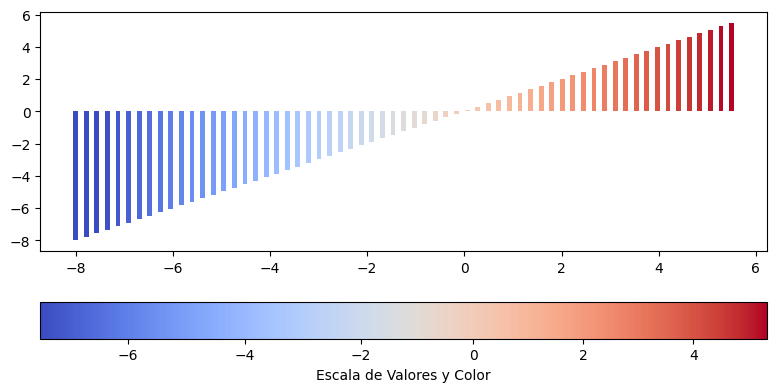

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

num_elementos = 63
values = np.linspace(-8, 5.5, num_elementos)

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(values, values, width=0.1, color=cmap(norm(values)))

mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

mappable.set_array(values)

cbar = fig.colorbar(mappable, ax=ax, orientation='horizontal', pad=0.15)
cbar.set_label('Escala de Valores y Color')

plt.tight_layout()
plt.savefig('figuras/colorbar.png', dpi=300)
plt.show()

In [10]:
# Crear un lienzo para exportar a PDF o PNG
canvas = KGMLCanvas(pathway, import_imagemap=True)
canvas.draw("figuras/ruta_modificada.pdf")